## Completion Time

In [1]:
import pandas as pd

df_control = pd.read_csv("df_control_updated.csv")
df_test = pd.read_csv("df_test_updated.csv")

In [2]:
df = pd.concat([df_test, df_control])

In [3]:
df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,visitor_id,visit_id,process_step,date_time
0,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56
1,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03
2,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35
3,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14
4,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34


In [4]:
df.isnull().sum()

client_id            0
clnt_tenure_yr      93
clnt_tenure_mnth    93
clnt_age            93
gendr               93
num_accts           93
bal                 93
calls_6_mnth        93
logons_6_mnth       93
variation            0
visitor_id           4
visit_id             4
process_step         4
date_time            4
dtype: int64

In [5]:
df.nunique()

client_id            50500
clnt_tenure_yr          53
clnt_tenure_mnth       469
clnt_age               158
gendr                    3
num_accts                7
bal                  50311
calls_6_mnth             7
logons_6_mnth            7
variation                2
visitor_id           56007
visit_id             69194
process_step             5
date_time           246737
dtype: int64

In [6]:
df['process_step'].unique()

<StringArray>
['start', 'step_1', 'step_2', 'step_3', 'confirm', nan]
Length: 6, dtype: str

In [7]:
# Droping missing values
df = df.dropna(subset=["process_step"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 275378 entries, 0 to 125093
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         275378 non-null  int64  
 1   clnt_tenure_yr    275285 non-null  float64
 2   clnt_tenure_mnth  275285 non-null  float64
 3   clnt_age          275285 non-null  float64
 4   gendr             275285 non-null  str    
 5   num_accts         275285 non-null  float64
 6   bal               275285 non-null  float64
 7   calls_6_mnth      275285 non-null  float64
 8   logons_6_mnth     275285 non-null  float64
 9   variation         275378 non-null  str    
 10  visitor_id        275378 non-null  str    
 11  visit_id          275378 non-null  str    
 12  process_step      275378 non-null  str    
 13  date_time         275378 non-null  str    
dtypes: float64(7), int64(1), str(6)
memory usage: 31.5 MB


In [9]:
# converting the "date_time" into a datetime type
df["date_time"] = pd.to_datetime(df["date_time"])

In [10]:
# Sort data
df = df.sort_values(["visit_id", "date_time"])


# Ordering the steps
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df["step_num"] = df["process_step"].map(step_order)

In [11]:
# Keep only After last 'start'
last_start = (
    df[df["process_step"] == "start"]
    .groupby("visit_id")["date_time"]
    .max()
    .reset_index()
    .rename(columns={"date_time": "last_start_time"})
)

df = df.merge(last_start, on="visit_id", how="left")

df = df[df["date_time"] >= df["last_start_time"]]

In [12]:
# Considering only last 'confirm'
last_confirm = (
    df[df["process_step"] == "confirm"]
    .groupby("visit_id")["date_time"]
    .max()
    .reset_index()
    .rename(columns={"date_time": "last_confirm_time"})
)

df = df.merge(last_confirm, on="visit_id", how="left")

In [13]:
# Applying confirm filter only if exists
f = df[
    (df["last_confirm_time"].isna()) | 
    (df["date_time"] <= df["last_confirm_time"])
]

In [14]:
# Computing time difference
df["next_time"] = df.groupby("visit_id")["date_time"].shift(-1)

df["step_duration"] = (df["next_time"] - df["date_time"]).dt.total_seconds()

In [15]:
# Removing only last rows
df = df.dropna(subset=["step_duration"])

In [16]:
# Aggregating
df_agg = df.groupby(
    ["visit_id", "process_step", "variation"]
)["step_duration"].mean().reset_index()
df_agg.head()

,visit_id,process_step,variation,step_duration
0,100019538_17884295066_43909,start,Test,5.0
1,100019538_17884295066_43909,step_1,Test,4.0
2,100019538_17884295066_43909,step_2,Test,113.0
3,100019538_17884295066_43909,step_3,Test,57.0
4,100022086_87870757897_149620,start,Test,22.0


In [27]:
# Let's drop confirm has it can be misleading
df_agg = df_agg[df_agg["process_step"] != "confirm"]

## Analyse outliers

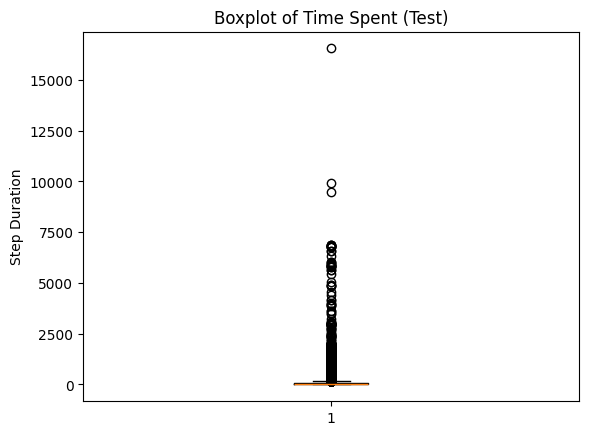

In [28]:
import matplotlib.pyplot as plt

plt.boxplot(df_agg["step_duration"].dropna())
plt.title("Boxplot of Time Spent (Test)")
plt.ylabel("Step Duration")
plt.show()

In [24]:
# Removing outliers
Q1 = df_agg["step_duration"].quantile(0.25)
Q3 = df_agg["step_duration"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [25]:
df_clean = df_agg[
    (df_agg["step_duration"] >= lower_bound) &
    (df_agg["step_duration"] <= upper_bound)
]

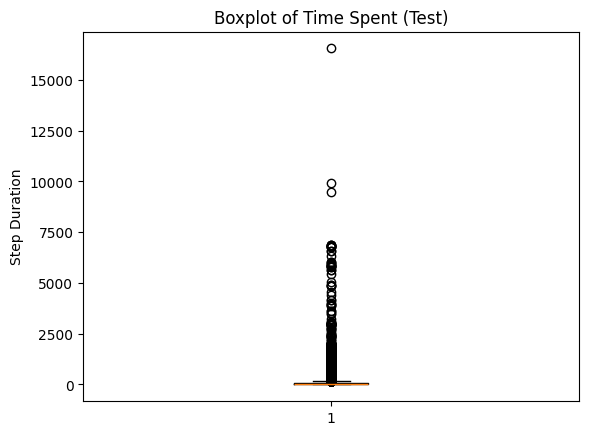

In [26]:
plt.boxplot(df_agg["step_duration"].dropna())
plt.title("Boxplot of Time Spent (Test)")
plt.ylabel("Step Duration")
plt.show()

In [29]:
df_agg["step_duration"].describe()

count    152333.000000
mean         71.609223
std         163.633513
min           0.000000
25%          14.000000
50%          36.000000
75%          77.000000
max       16552.000000
Name: step_duration, dtype: float64

In [30]:
upper_bound = df_agg["step_duration"].quantile(0.99)

df_clean = df_agg[df_agg["step_duration"] <= upper_bound]

In [31]:
df_clean["step_duration"].max()

np.float64(609.0)

## Average time for each step across all visits

In [46]:
df_avg = df_clean.groupby(["variation", "process_step"])["step_duration"].mean().reset_index()
print(df_avg)

  variation process_step  step_duration
0   Control        start      35.242046
1   Control       step_1      34.502739
2   Control       step_2      89.317049
3   Control       step_3     112.111816
4      Test        start      28.358186
5      Test       step_1      36.412732
6      Test       step_2      85.422477
7      Test       step_3      98.124348


## ANOVA - Within each group

## Hypothesis


- H₀ (Null Hypothesis): All step completion times are the same within the group
- H₁ (Alternative Hypothesis): All step completion times differs within the group

In [37]:
from scipy.stats import f_oneway

steps = ["start", "step_1", "step_2", "step_3"]

# TEST group
test_data = [
    df_clean[(df_clean["variation"] == "Test") & (df_clean["process_step"] == step)]["step_duration"]
    for step in steps
]

f_stat_test, p_value_test = f_oneway(*test_data)

print("Test group ANOVA p-value:", p_value_test)


# CONTROL group
control_data = [
    df_clean[(df_clean["variation"] == "Control") & (df_clean["process_step"] == step)]["step_duration"]
    for step in steps
]

f_stat_control, p_value_control = f_oneway(*control_data)

print("Control group ANOVA p-value:", p_value_control)

Test group ANOVA p-value: 0.0
Control group ANOVA p-value: 0.0


**Conclusions:** 

To evaluate whether completion times differ across the steps of the process within each group, a one-way ANOVA test was performed separately for the Test and Control groups.

For both groups, the results yielded extremely small p-values (p < 0.001, reported as 0.0 due to rounding), indicating strong evidence against the null hypothesis.

Therefore, we reject the null hypothesis that all step completion times are equal within each group.

This means that there are statistically significant differences in the average time spent across the different steps of the process in both the Test and Control groups.

Step duration varies significantly across the funnel in both groups, confirming non-uniform user effort throughout the process.

## T-TEST
**Test vs Control**

## Hypothesis

Null Hypothesis ($H_0$)): For each step of the process, the mean completion time is equal between the Test and Control groups.

Alternative Hypothesis ($H_a$)): For each step of the process, the mean completion time differs between the Test and Control groups.

In [33]:
from scipy.stats import ttest_ind

steps = ["start", "step_1", "step_2", "step_3"]

for step in steps:
    test_vals = df_clean[
        (df_clean["variation"] == "Test") &
        (df_clean["process_step"] == step)
    ]["step_duration"]

    control_vals = df_clean[
        (df_clean["variation"] == "Control") &
        (df_clean["process_step"] == step)
    ]["step_duration"]

    t_stat, p_value = ttest_ind(test_vals, control_vals, equal_var=False)

    print(f"{step} → p-value: {p_value}")

start → p-value: 8.900845966064448e-36
step_1 → p-value: 2.549219598978714e-05
step_2 → p-value: 2.7240892570837504e-07
step_3 → p-value: 1.8685698758535584e-31


**Conclusions:**

There are statistically significant differences in completion times between the Test and Control groups at every step of the process. Therefore, we reject the null hypothesis that for each step of the process, the mean completion time is equal between the Test and Control groups.


This indicates that the new interface has a consistent and measurable impact on user behavior across the entire funnel.

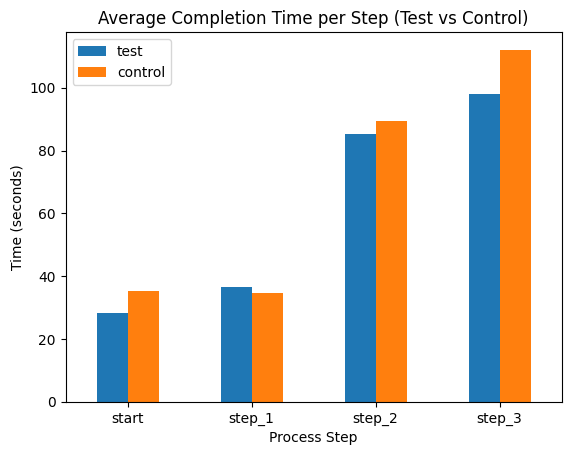

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
    "step": ["start", "step_1", "step_2", "step_3"],
    "test": [28.36, 36.41, 85.42, 98.12],
    "control": [35.24, 34.50, 89.32, 112.11]
})

data = data.set_index("step")

data.plot(kind="bar")

plt.title("Average Completion Time per Step (Test vs Control)")
plt.xlabel("Process Step")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)

plt.show()

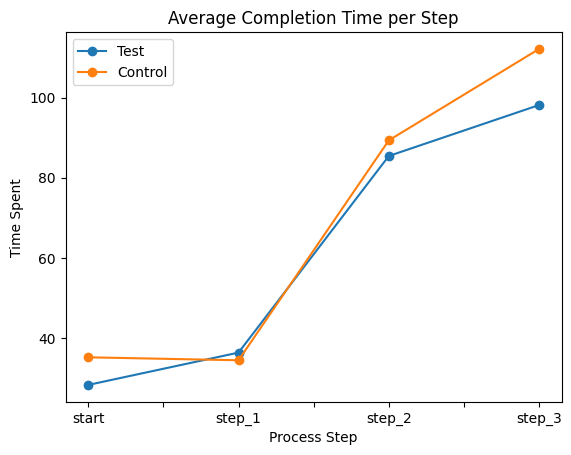

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
test = pd.Series({
    "start": 28.358186,
    "step_1": 36.412732,
    "step_2": 85.422477,
    "step_3":  98.124348
})

control = pd.Series({
    "start": 35.242046,
    "step_1": 34.502739,
    "step_2": 89.317049,
    "step_3": 112.111816
})

# Combine
df_plot = pd.DataFrame({
    "Test": test,
    "Control": control
})

# Plot
df_plot.plot(marker='o')
plt.title("Average Completion Time per Step")
plt.ylabel("Time Spent")
plt.xlabel("Process Step")
plt.xticks(rotation=0)
plt.show()

In [48]:
df_avg.to_csv("completion_time_francisca.csv", index=False)